# Sampler Quickstart — Binary Lens Static

A minimal example of Bayesian sampling with `lcbinint`:

1. Generate synthetic data: sparse baseline + dense follow-up around the caustic
2. Build a `bayes.Model` with priors and flux marginalisation
3. Find the MAP (Levenberg–Marquardt, starting from the input parameters)
4. Initialise walkers with the Hessian at the MAP (`hessian_init=True`)
5. Run the ensemble sampler and inspect the posterior

> **Note on parameter choice**  
> Binary lens posteriors can be multimodal (close/wide degeneracy, α degeneracy).  
> The parameters here (`s=1.3, q=0.1`) give a well-behaved unimodal posterior.  
> For degenerate problems a parallel-tempering sampler or a grid-based search is preferred.

In [1]:
import sys
from pathlib import Path

for build_dir in ("build", "build_new"):
    p = next(
        (r / build_dir for r in (Path.cwd(), *Path.cwd().parents) if (r / build_dir).is_dir()),
        None,
    )
    if p is not None:
        sys.path.insert(0, str(p))
        break

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import lcbinint as lci

# Retina / high-DPI output
mpl.rcParams["figure.dpi"] = 150
try:
    get_ipython().run_line_magic("config", "InlineBackend.figure_format = 'retina'")
except NameError:
    pass

print("lcbinint:", lci.__file__)

lcbinint: /rogue1_8/nunota/lcbinint/build/lcbinint/__init__.py


## 1. Synthetic Data

We mimic a realistic observing strategy:
- **Baseline**: 40 uniformly-spaced points over the full ±25 d window
- **Anomaly follow-up**: 60 points concentrated in `[t0−12, t0+8]` to cover the two caustic crossings

Total: 100 points with ~70 in the high-magnification region.

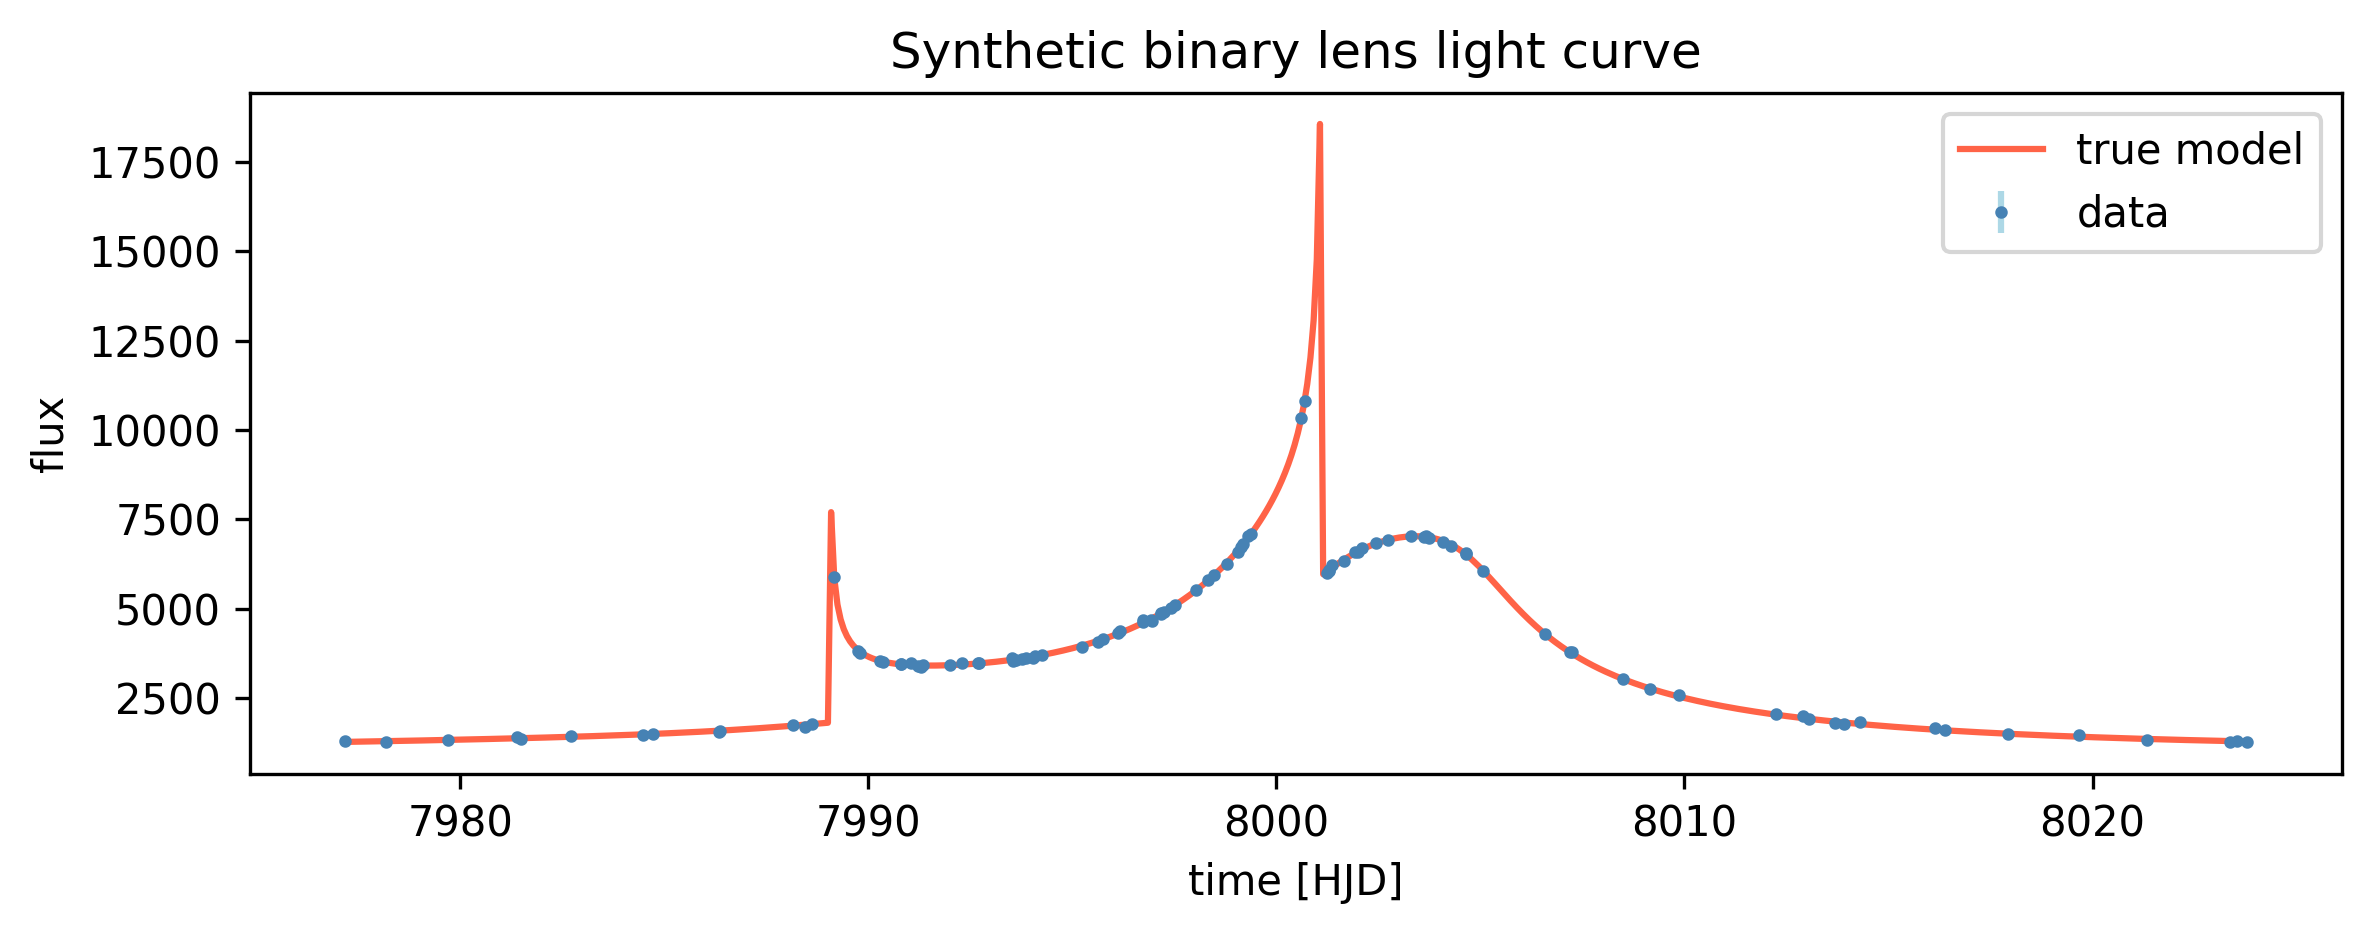

True parameters: {'t0': 8000.0, 'tE': 20.0, 'u0': 0.1, 's': 1.3, 'q': 0.1, 'alpha': 0.5}
n_data=100  peak S/N=359
Points with mag>3: 70  (caustic region well covered)


In [2]:
rng = np.random.default_rng(42)

# Ground-truth parameters
TRUE = dict(t0=8000.0, tE=20.0, u0=0.10, s=1.3, q=0.10, alpha=0.5)
Fs_true, Fb_true, sigma = 1000.0, 50.0, 30.0

# Two-cadence sampling
t_base   = np.sort(rng.uniform(TRUE["t0"] - 25, TRUE["t0"] + 25, 40))
t_follow = np.sort(rng.uniform(TRUE["t0"] - 12, TRUE["t0"] +  8, 60))
times    = np.sort(np.concatenate([t_base, t_follow]))

lc_ref   = lci.lc.LightCurve()
mag_true = lc_ref(times, **TRUE)
flux_obs = Fs_true * mag_true + Fb_true + rng.normal(0, sigma, len(times))
flux_err = np.full(len(times), sigma)

t_dense = np.linspace(times[0], times[-1], 600)
fig, ax = plt.subplots(figsize=(8, 3.2))
ax.errorbar(times, flux_obs, flux_err, fmt=".", ms=4,
            color="steelblue", ecolor="lightblue", label="data", zorder=3)
ax.plot(t_dense, Fs_true * lc_ref(t_dense, **TRUE) + Fb_true,
        color="tomato", lw=1.5, label="true model")
ax.set(xlabel="time [HJD]", ylabel="flux", title="Synthetic binary lens light curve")
ax.legend()
plt.tight_layout()
plt.show()
print("True parameters:", TRUE)
print(f"n_data={len(times)}  peak S/N={Fs_true*mag_true.max()/sigma:.0f}")
print(f"Points with mag>3: {(mag_true>3).sum()}  (caustic region well covered)")

## 2. Model Setup

`model.flux()` analytically marginalises the linear flux parameters $F_s$ and $F_b$,  
so only the 6 lens parameters are sampled.

`LogUniform` for `q` samples in log space — important when `q` can span orders of magnitude.

In [3]:
data     = lci.obs.LightCurveData(times, flux_obs, flux_err, name="synthetic")
lc_model = lci.lc.LightCurve()
model    = lci.bayes.Model(light_curve=lc_model, data=data)

model.param("t0",    lci.bayes.Uniform(7990, 8010))
model.param("tE",    lci.bayes.Uniform(5, 60))
model.param("u0",    lci.bayes.Uniform(0.0, 1.0))
model.param("s",     lci.bayes.Uniform(0.5, 2.0))
model.param("q",     lci.bayes.LogUniform(1e-3, 0.5))  # sampled in log space
model.param("alpha", lci.bayes.Uniform(0, np.pi))

model.flux()        # marginalise Fs, Fb analytically
model.likelihood()  # Gaussian likelihood

print("Params to sample:", model.param_names)

# Sanity check: log_prob at truth (q is passed in log space)
theta_true_s = [TRUE["t0"], TRUE["tE"], TRUE["u0"], TRUE["s"],
                np.log(TRUE["q"]), TRUE["alpha"]]
print(f"log_prob at truth: {model.log_prob(theta_true_s):.2f}")
print(f"chi2     at truth: {model.chi2(theta_true_s):.2f}  (n_data={model.n_data})")

Params to sample: ['t0', 'tE', 'u0', 's', 'q', 'alpha']
log_prob at truth: -58.32
chi2     at truth: 95.88  (n_data=100)


## 3. MAP Estimate (Levenberg–Marquardt)

Binary lens posteriors are sharply peaked.  
We start LM from the known input parameters to quickly find the MAP,  
then use the Hessian at the MAP to initialise the walkers (`hessian_init=True`).

In a real analysis you would replace the starting point with the output of a grid search  
or a global optimiser such as `lci.optimize.DifferentialEvolution`.

In [4]:
lm      = lci.optimize.LevenbergMarquardt()
res_map = lm.minimize(model, start=theta_true_s)

print(f"LM success={res_map.success}  chi2={res_map.chi2:.4f}  log_prob={res_map.log_prob:.4f}")
print("MAP parameters:")
for k, v in res_map.parameters.items():
    print(f"  {k:6s}: {v:.6f}   (truth: {TRUE[k]:.6f})")

LM success=True  chi2=92.9357  log_prob=-56.8480
MAP parameters:
  alpha : 0.499951   (truth: 0.500000)
  s     : 1.299690   (truth: 1.300000)
  u0    : 0.099914   (truth: 0.100000)
  q     : 0.098958   (truth: 0.100000)
  tE    : 20.065716   (truth: 20.000000)
  t0    : 8000.028850   (truth: 8000.000000)


## 4. MCMC Sampling

`hessian_init=True` computes the Hessian of the negative log-posterior at the MAP  
and disperses walkers according to the resulting Laplace covariance.  
32 walkers, 500 burn-in + 4000 production steps (~11 s with 100 data points).

In [5]:
opts  = lci.SamplerOptions(nwalkers=32, log_every=500, auto_stop=False)
chain = lci.run_sampler(model, nsteps=4000, burnin=500,
                        start=res_map, hessian_init=True, options=opts)

print(chain)
print(f"Acceptance fraction: {chain.acceptance_fraction:.3f}  (ideal ≈ 0.2–0.5)")

taus = chain.tau()
tau_max = max(taus)
print(f"Autocorrelation times: {dict(zip(chain.param_names, [f'{v:.0f}' for v in taus]))}")
print(f"nsteps / tau_max = {4000 / tau_max:.1f}  (need > 50 for full convergence)")

lcbinint sampler | 32 walkers | 6 params | burnin=500 | nsteps=4000


  [burnin 500/500]  accept=0.268


  Burnin done. Starting production run.


  [step  500/4000]  accept=0.270  log_prob=-60.99  elapsed=2.4s


  [step 1000/4000]  accept=0.271  log_prob=-60.41  elapsed=3.6s


...

  [step 3000/4000]  accept=0.274  log_prob=-60.55  elapsed=8.5s


  [step 3500/4000]  accept=0.273  log_prob=-60.76  elapsed=9.7s


  [step 4000/4000]  accept=0.273  log_prob=-60.10  elapsed=10.9s


  Done. 4000 production steps | accept=0.273 | elapsed=10.9s


<sample.Chain nsteps=4000 nwalkers=32 ndim=6 acceptance=0.272>
Acceptance fraction: 0.273  (ideal ≈ 0.2–0.5)
Autocorrelation times: {'t0': '99', 'tE': '111', 'u0': '99', 's': '91', 'q': '101', 'alpha': '88'}
nsteps / tau_max = 36.1  (need > 50 for full convergence)


## 5. Chain Traces

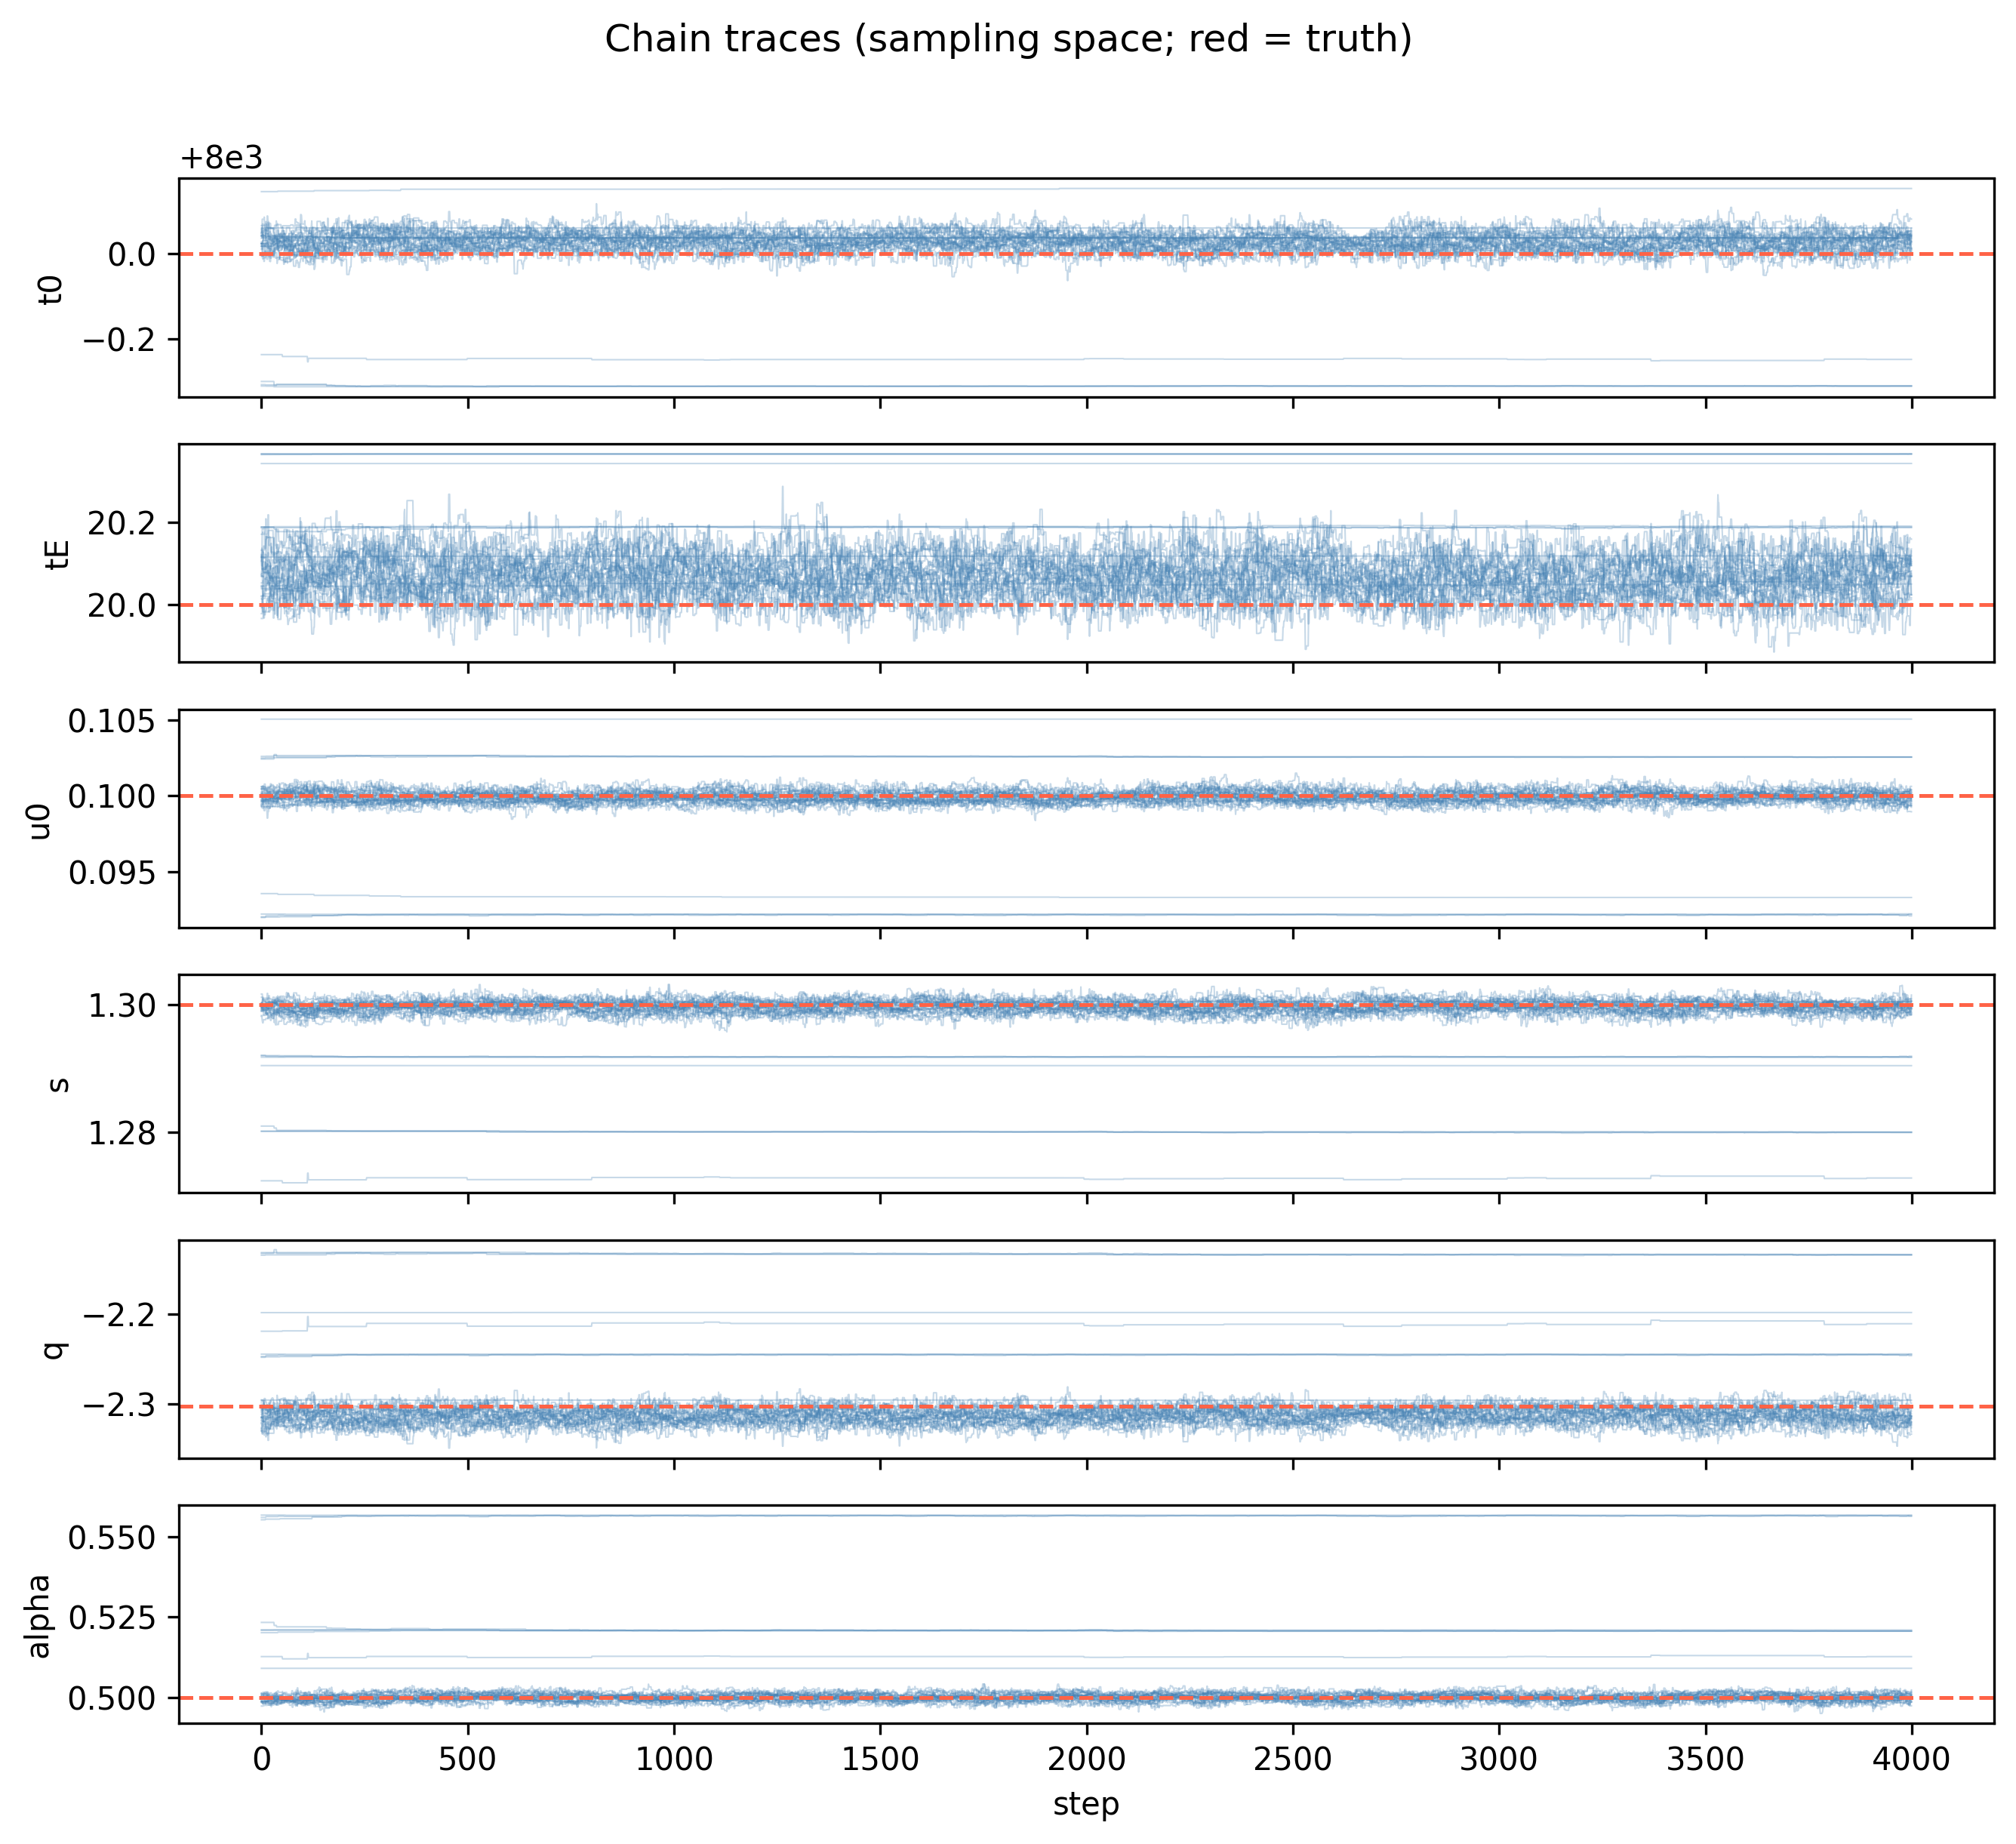

In [6]:
labels     = model.param_names
transforms = chain.transforms          # ["" or "log"] per param
chain_3d   = chain.get_chain()         # (nsteps, nwalkers, ndim) — sampling space
true_vals  = [TRUE["t0"], TRUE["tE"], TRUE["u0"], TRUE["s"], TRUE["q"], TRUE["alpha"]]

fig, axes = plt.subplots(len(labels), 1, figsize=(9, 8), sharex=True)
for i, (ax, lbl, tv) in enumerate(zip(axes, labels, true_vals)):
    ax.plot(chain_3d[:, :, i], alpha=0.3, lw=0.5, color="steelblue")
    ax.set_ylabel(lbl)
    tv_s = np.log(tv) if (transforms and transforms[i] == "log") else tv
    ax.axhline(tv_s, color="tomato", lw=1.2, ls="--")
axes[-1].set_xlabel("step")
fig.suptitle("Chain traces (sampling space; red = truth)", y=1.01)
plt.tight_layout()
plt.show()

## 6. Posterior Marginals

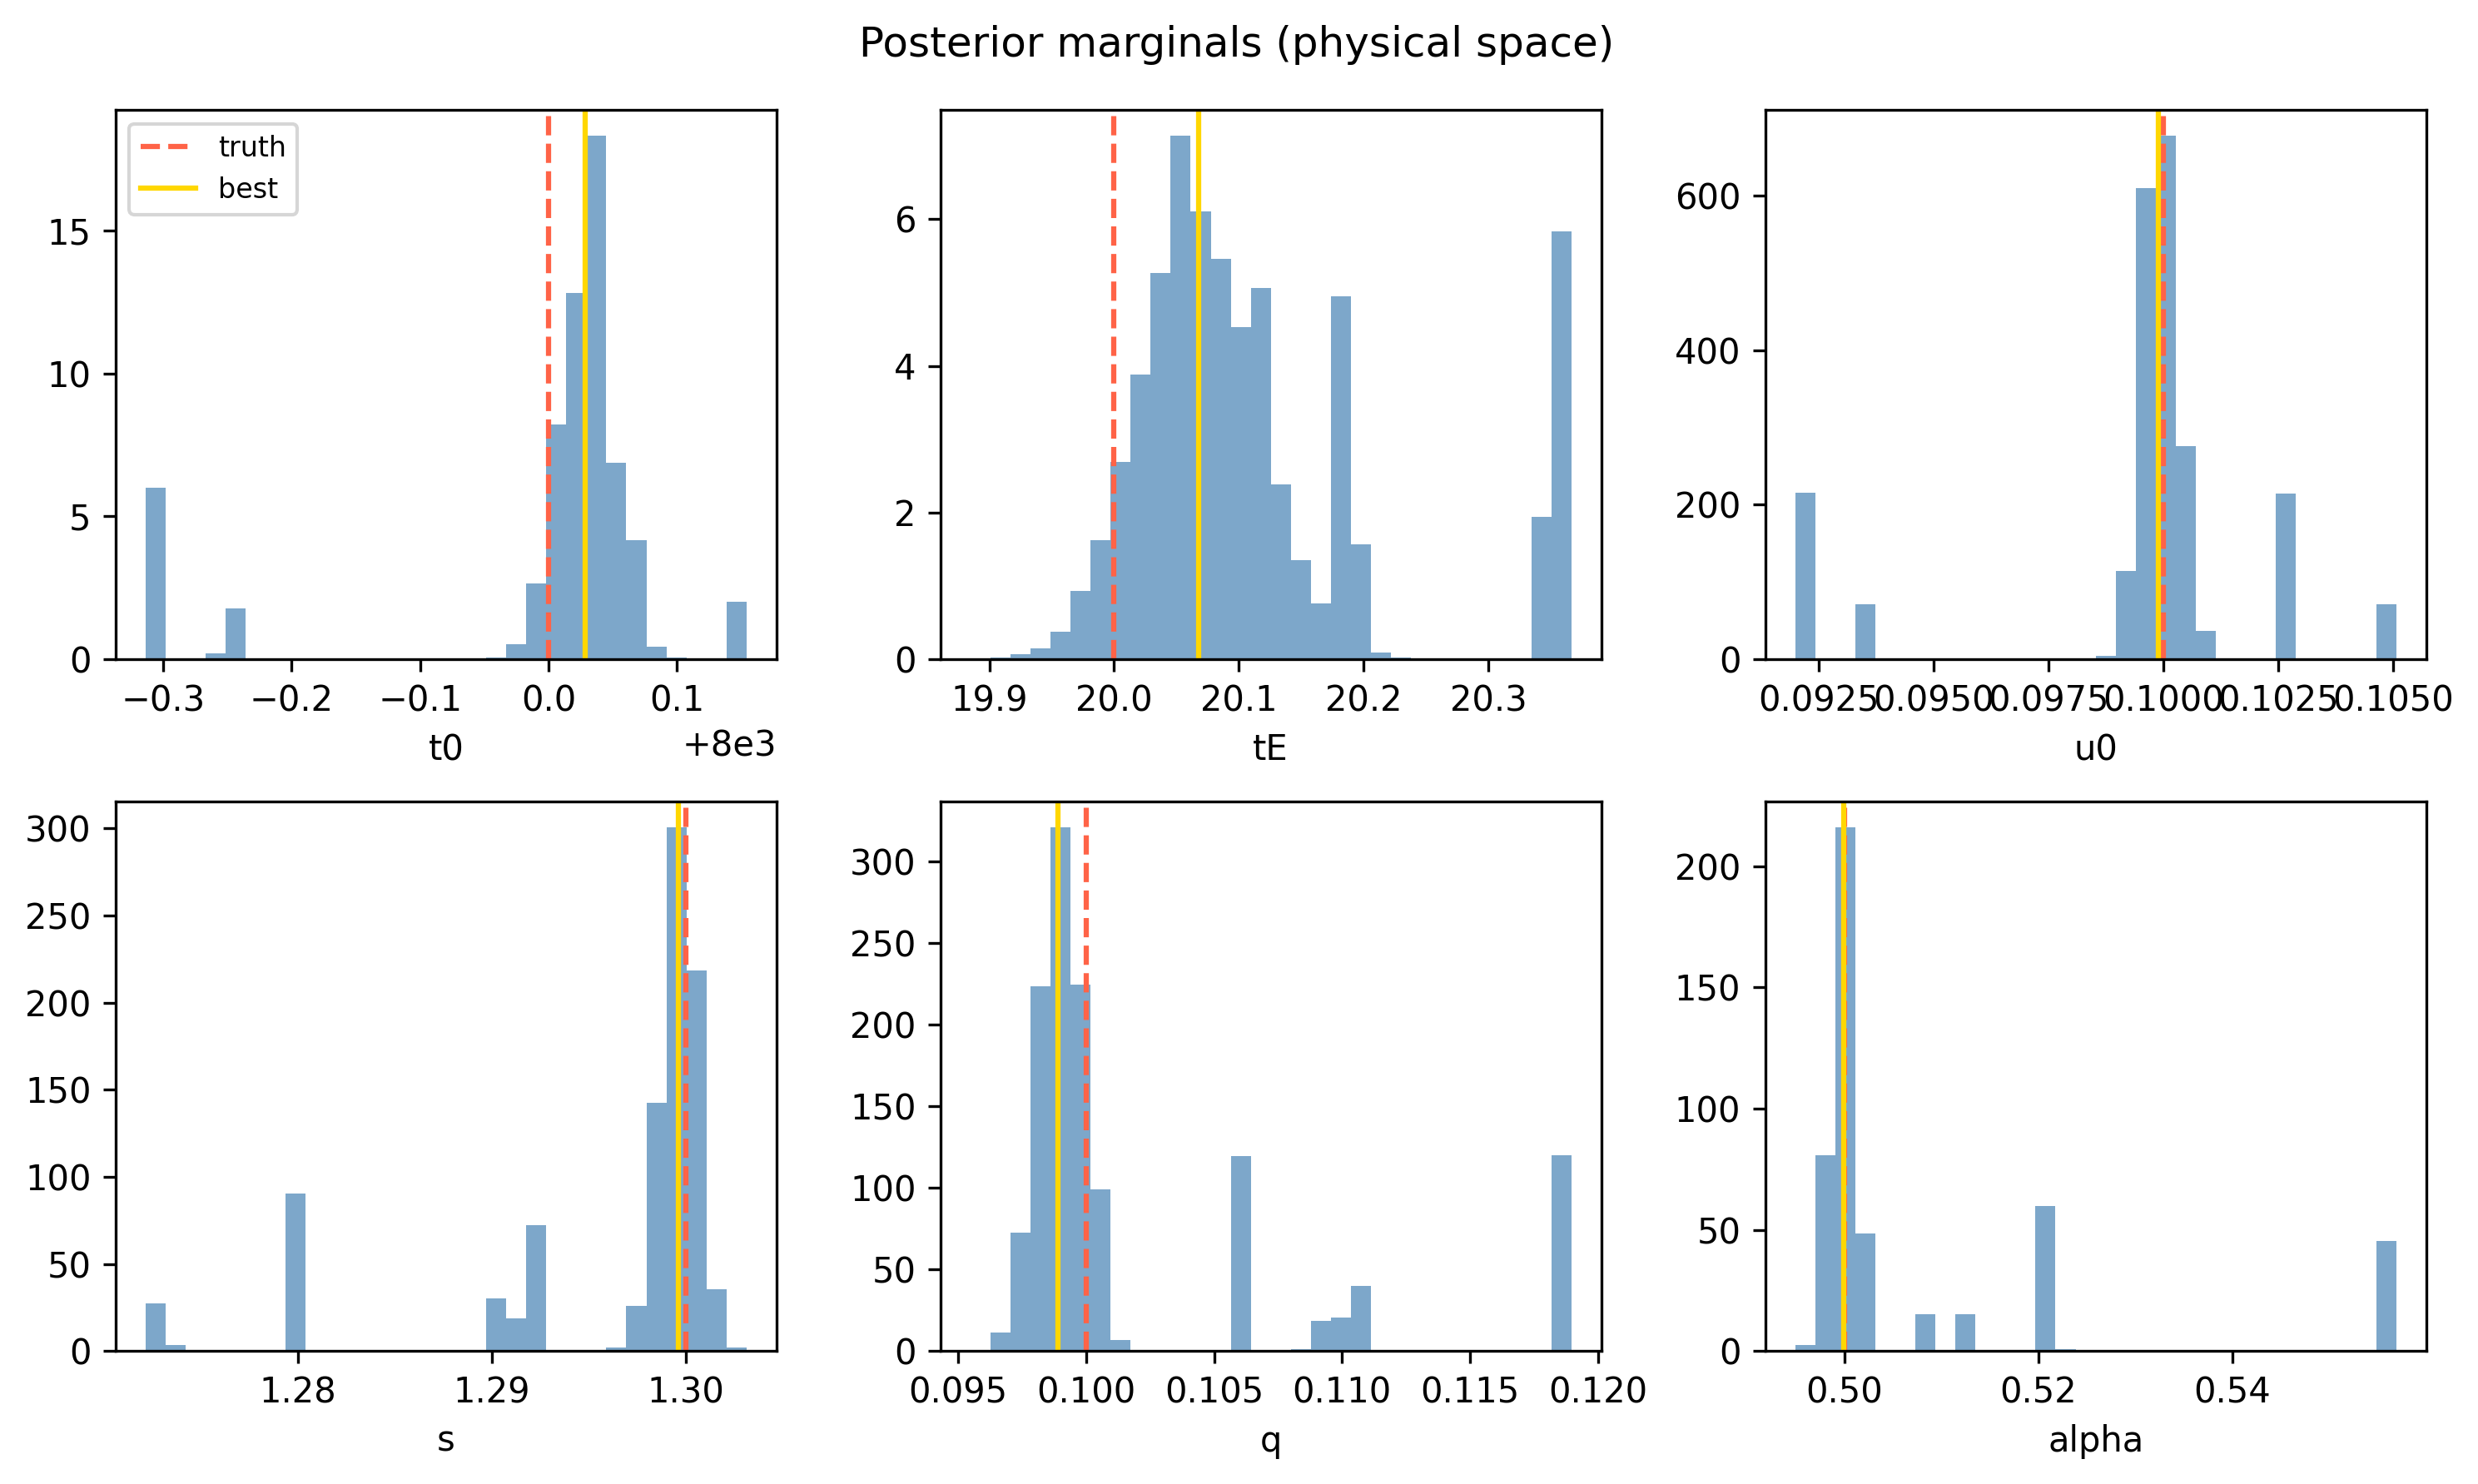

param      truth      best    median        lo        hi
t0      8000.00000  8000.02823  8000.02902  7999.99440  8000.05071
tE      20.00000  20.06803  20.08560  20.02999  20.18947
u0       0.10000   0.09990   0.09991   0.09933   0.10057
s        1.30000   1.29963   1.29928   1.29176   1.30037
q        0.10000   0.09891   0.09942   0.09832   0.10596


alpha    0.50000   0.49997   0.50048   0.49902   0.52081


In [7]:
samples_phys = chain.samples        # (nsteps × nwalkers, ndim) — physical space
flat_lp      = chain.flat_log_prob
best_idx     = int(np.argmax(flat_lp))
best_phys    = samples_phys[best_idx]

fig, axes = plt.subplots(2, 3, figsize=(10, 6))
for i, (ax, lbl, tv) in enumerate(zip(axes.flat, labels, true_vals)):
    ax.hist(samples_phys[:, i], bins=30, color="steelblue", alpha=0.7, density=True)
    ax.axvline(tv,           color="tomato", lw=1.5, ls="--", label="truth")
    ax.axvline(best_phys[i], color="gold",   lw=1.5, ls="-",  label="best")
    ax.set_xlabel(lbl)
    if i == 0:
        ax.legend(fontsize=8)
plt.suptitle("Posterior marginals (physical space)")
plt.tight_layout()
plt.show()

print(f"{'param':6s}  {'truth':>8s}  {'best':>8s}  {'median':>8s}  {'lo':>8s}  {'hi':>8s}")
for i, (lbl, tv) in enumerate(zip(labels, true_vals)):
    s = chain.summary()[lbl]
    print(f"{lbl:6s}  {tv:8.5f}  {best_phys[i]:8.5f}  {s['median']:8.5f}  {s['lo']:8.5f}  {s['hi']:8.5f}")

## 7. Best-Fit Overlay

We plot the sample with the highest log-posterior (best) rather than the median —  
it is a valid posterior draw and closest to the MAP, giving the cleanest residuals.

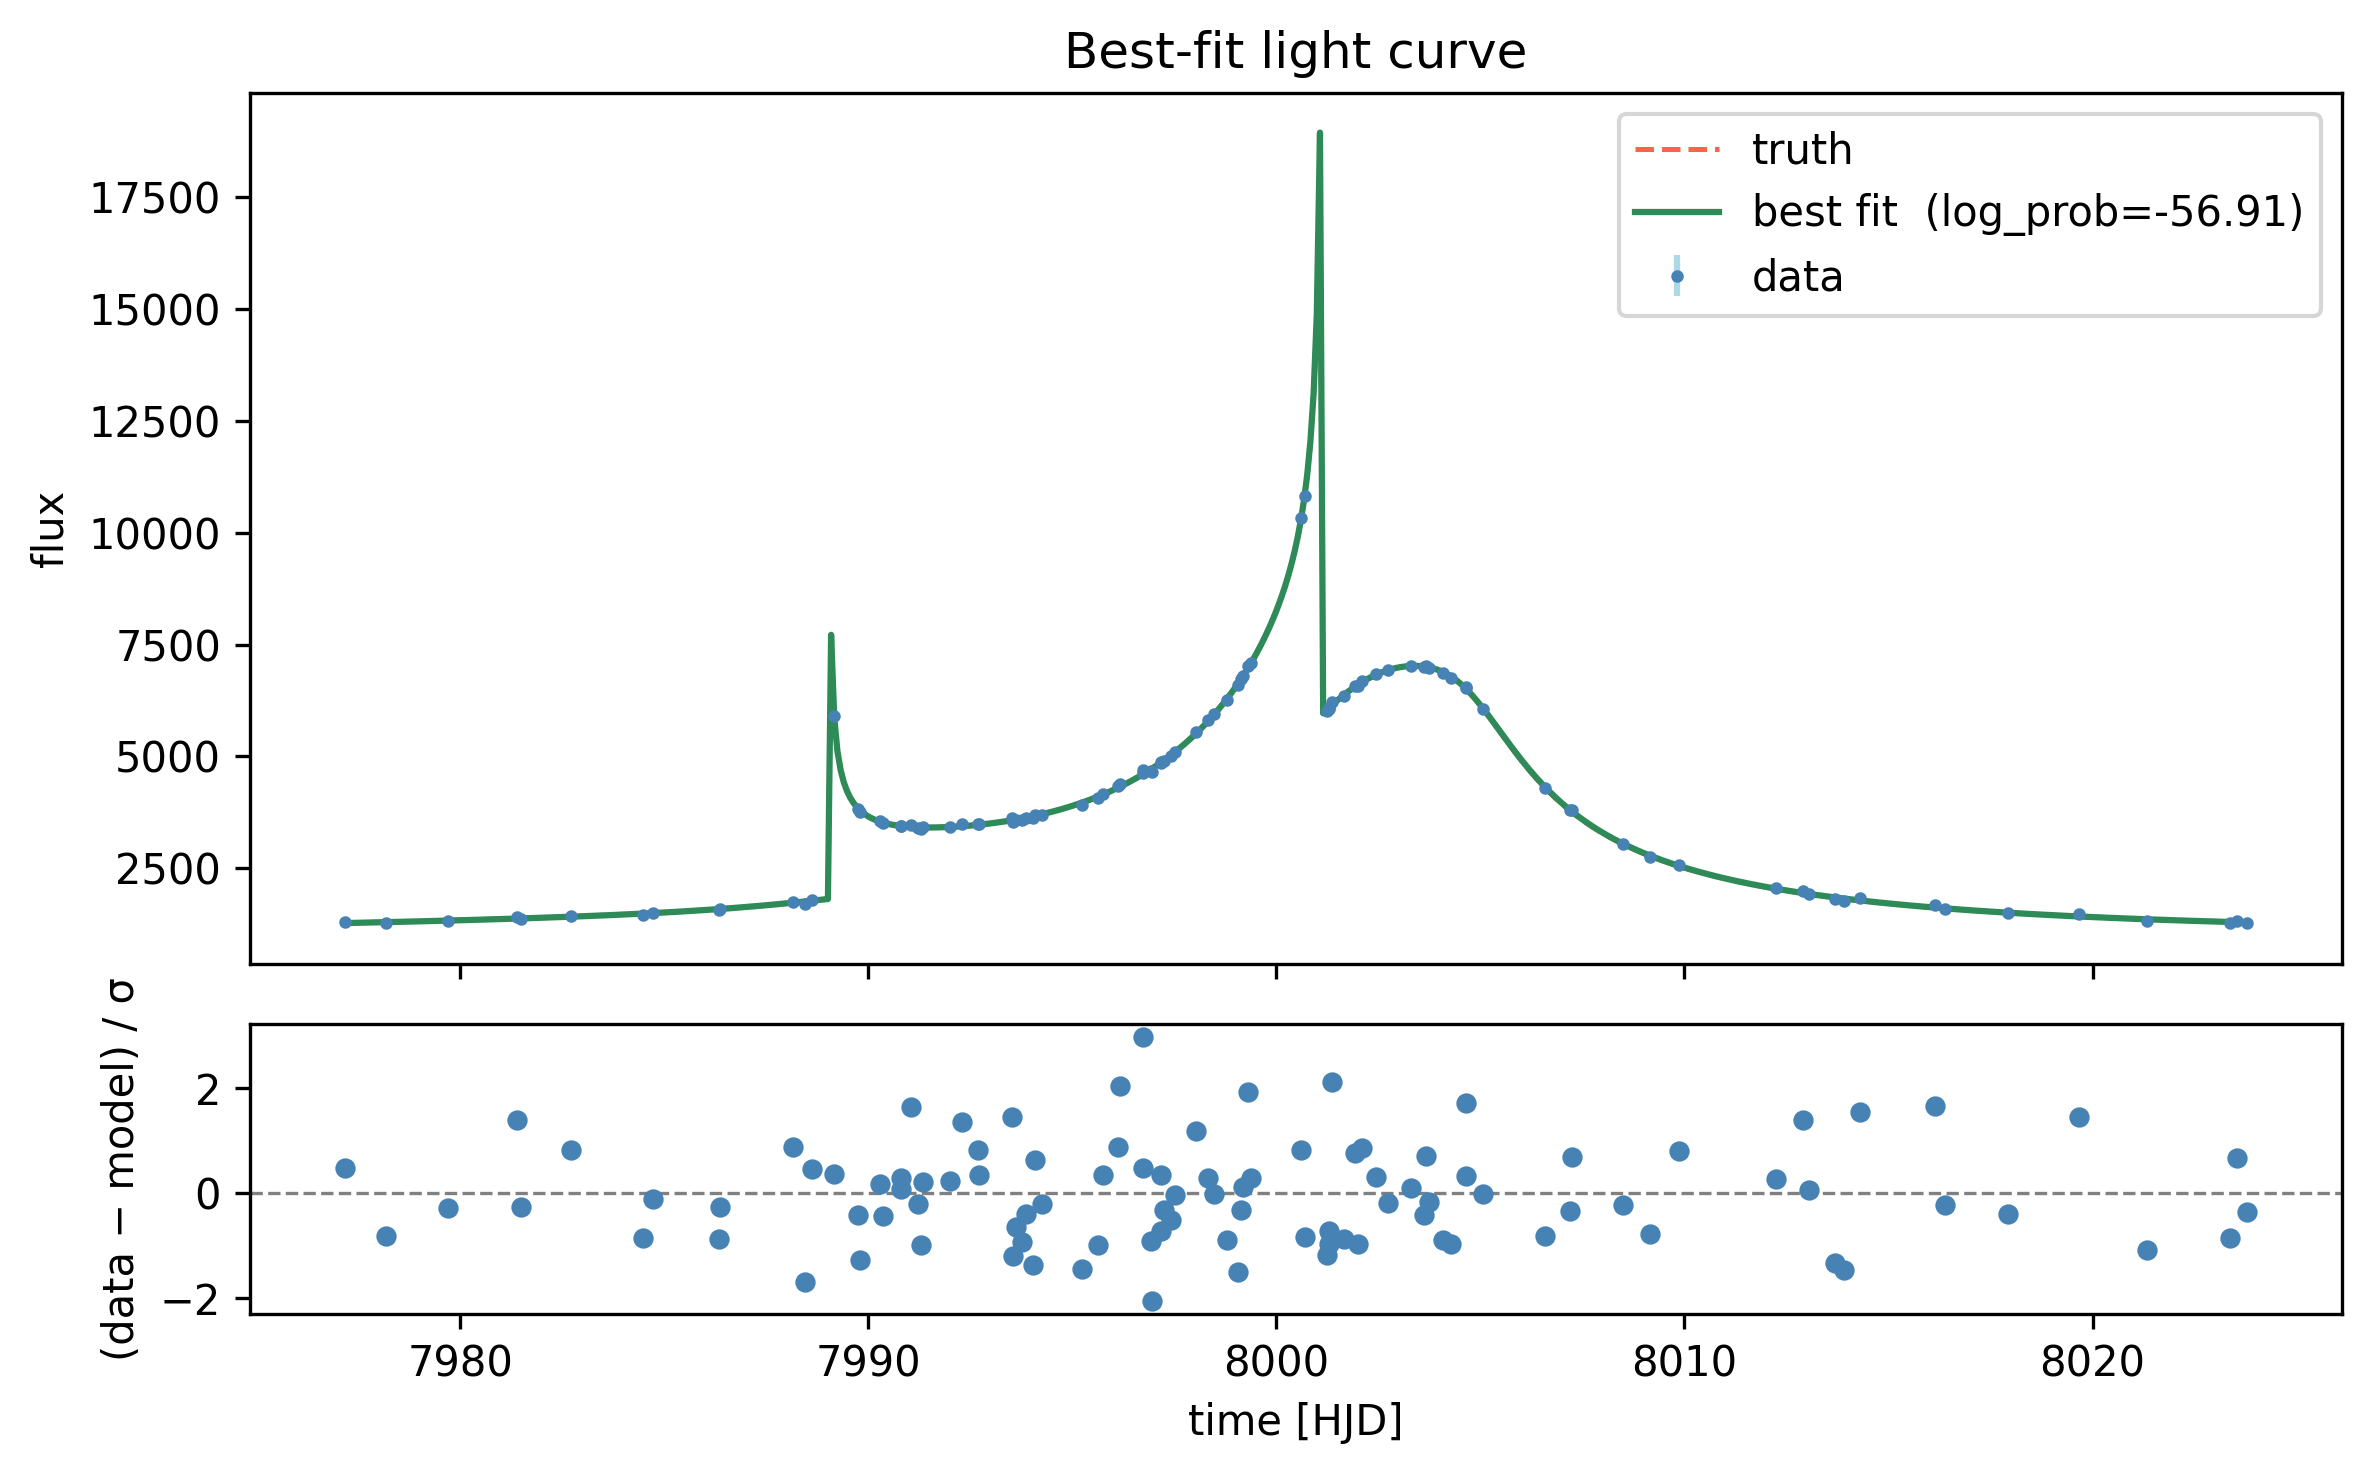

Recovered Fs = 998.5  (truth 1000.0)
Recovered Fb = 48.2  (truth 50.0)


In [8]:
# best sample in sampling space (needed for model.fluxes)
best_theta_raw = chain.flat_samples[best_idx].tolist()
fluxes_best    = model.fluxes(best_theta_raw)
Fs_best = fluxes_best["synthetic"]["Fs"]
Fb_best = fluxes_best["synthetic"]["Fb"]

p_best    = dict(zip(labels, best_phys))
mag_best  = lc_model(t_dense, **p_best)
flux_best = Fs_best * mag_best + Fb_best

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 5), sharex=True,
                                gridspec_kw={"height_ratios": [3, 1]})
ax1.errorbar(times, flux_obs, flux_err, fmt=".", ms=4,
             color="steelblue", ecolor="lightblue", zorder=3, label="data")
ax1.plot(t_dense, Fs_true * lc_ref(t_dense, **TRUE) + Fb_true,
         color="tomato", lw=1.2, ls="--", label="truth")
ax1.plot(t_dense, flux_best, color="seagreen", lw=1.5,
         label=f"best fit  (log_prob={flat_lp[best_idx]:.2f})")
ax1.set_ylabel("flux")
ax1.set_title("Best-fit light curve")
ax1.legend()

flux_at_data = Fs_best * lc_model(times, **p_best) + Fb_best
ax2.scatter(times, (flux_obs - flux_at_data) / flux_err,
            s=15, color="steelblue", zorder=3)
ax2.axhline(0, color="gray", lw=0.8, ls="--")
ax2.set(xlabel="time [HJD]", ylabel="(data − model) / σ")
plt.tight_layout()
plt.show()

print(f"Recovered Fs = {Fs_best:.1f}  (truth {Fs_true:.1f})")
print(f"Recovered Fb = {Fb_best:.1f}  (truth {Fb_true:.1f})")